In [4]:
# Display all column names
print(df.columns)

['Provider Code', 'Procedure', 'Revision Flag', 'Year', 'Age Band', 'Gender', 'Pre-Op Q Assisted', 'Pre-Op Q Assisted By', 'Pre-Op Q Symptom Period', 'Pre-Op Q Previous Surgery', 'Pre-Op Q Living Arrangements', 'Pre-Op Q Disability', 'Heart Disease', 'High Bp', 'Stroke', 'Circulation', 'Lung Disease', 'Diabetes', 'Kidney Disease', 'Nervous System', 'Liver Disease', 'Cancer', 'Depression', 'Arthritis', 'Pre-Op Q Mobility', 'Pre-Op Q Self-Care', 'Pre-Op Q Activity', 'Pre-Op Q Discomfort', 'Pre-Op Q Anxiety', 'Pre-Op Q EQ5D Index Profile', 'Pre-Op Q EQ5D Index', 'Post-Op Q EQ5D Index Profile', 'Knee Replacement Pre-Op Q Pain', 'Knee Replacement Pre-Op Q Night Pain', 'Knee Replacement Pre-Op Q Washing', 'Knee Replacement Pre-Op Q Transport', 'Knee Replacement Pre-Op Q Walking', 'Knee Replacement Pre-Op Q Standing', 'Knee Replacement Pre-Op Q Limping', 'Knee Replacement Pre-Op Q Kneeling', 'Knee Replacement Pre-Op Q Work', 'Knee Replacement Pre-Op Q Confidence', 'Knee Replacement Pre-Op Q S

In [5]:
# Third party packages.
import os

import pandas as pd             # Data handling
import polars as pl             # Data handling ('Blazingly fast DataFrames'), alternative to Pandas.
import polars.selectors as cs   # Select columns of particular type.
import numpy as np              # Numeric calculations
import pickle                   # Save and load data
import altair as alt            # Visualize data
import seaborn as sns           # Visualize data
import matplotlib.pyplot as plt # Visualize data

from icecream import ic         # Print variables.

from sklearn.model_selection    import train_test_split     # Split data
from sklearn.preprocessing      import StandardScaler       # Scale data
from sklearn.linear_model       import LinearRegression     # Linear regression
from sklearn.linear_model       import LassoCV              # Lasso regression
from sklearn.preprocessing      import OneHotEncoder        # One hot encoding
from sklearn.neighbors          import KNeighborsRegressor  # KNN regression
from sklearn.model_selection    import GridSearchCV         # Grid search

### Load Parquet File

In [6]:
df = pl.read_parquet(f'../Experiment/Knee/data/interim/2.1-train.parquet')
df.shape

(94550, 46)

### Correlation

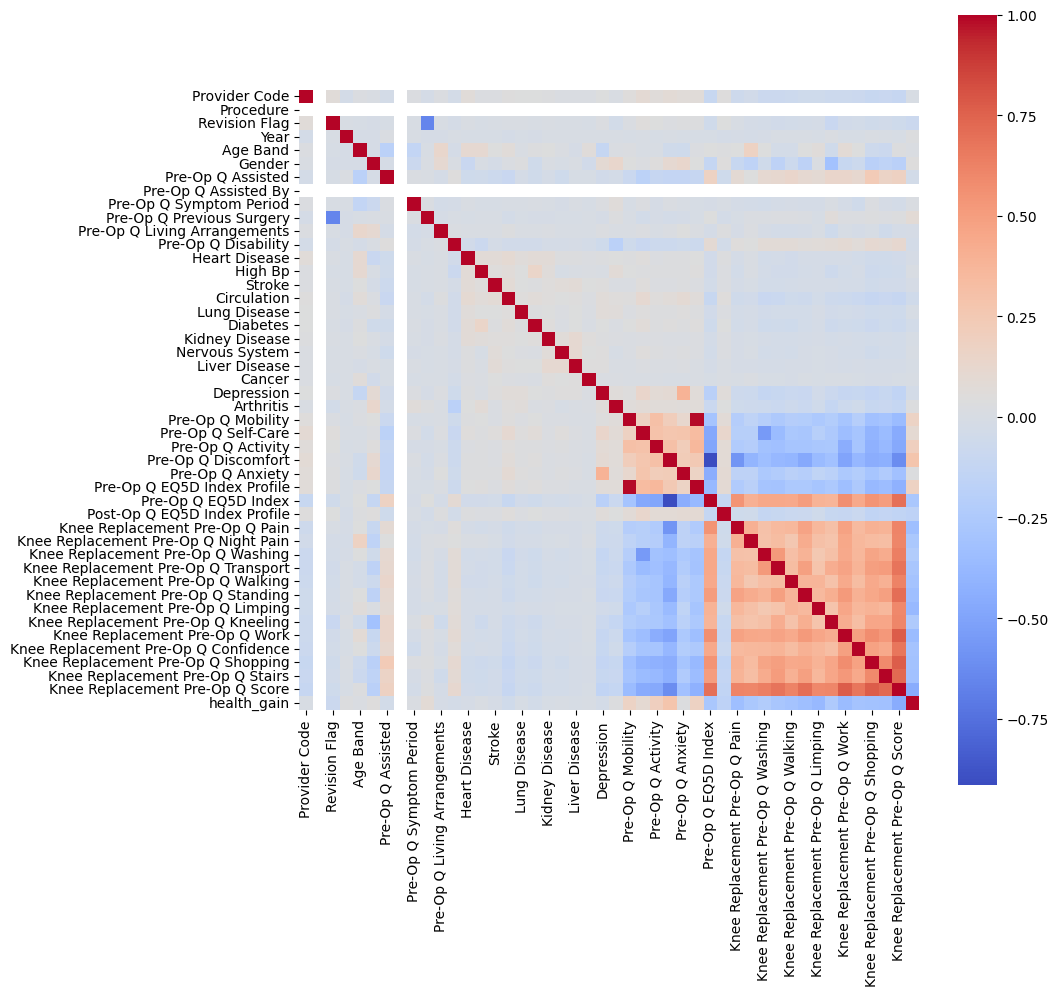

In [7]:
plt.figure(figsize=(10, 10)) 

sns.heatmap(
    data   = df.to_pandas().corr(),  # Polars requires conversion for correlation
    annot  = False,
    square = True,
    cmap   = 'coolwarm'
);

In [8]:
# Calculate correlations with health gain and create sorted table
corr_matrix = df.to_pandas().corr()

# Get correlations with 'health_gain' (adjust column name if different)
# Look for health gain column
health_gain_col = [col for col in df.columns if 'health' in col.lower() and 'gain' in col.lower()]
if health_gain_col:
    target = health_gain_col[0]
    corr_with_target = corr_matrix[target].drop(target).sort_values()
    
    # Create a nice table
    corr_table = pd.DataFrame({
        'Variable': corr_with_target.index,
        'Correlation with Health Gain': corr_with_target.values
    }).reset_index(drop=True)
    
    print(f"Correlations with '{target}' (sorted ascending):\n")
    print(corr_table.to_string(index=False))
else:
    print("Health gain column not found. Available columns:")
    print(df.columns)

Correlations with 'health_gain' (sorted ascending):

                            Variable  Correlation with Health Gain
     Knee Replacement Pre-Op Q Score                     -0.453938
   Knee Replacement Pre-Op Q Limping                     -0.371028
      Knee Replacement Pre-Op Q Work                     -0.359516
  Knee Replacement Pre-Op Q Standing                     -0.334769
      Knee Replacement Pre-Op Q Pain                     -0.331178
    Knee Replacement Pre-Op Q Stairs                     -0.316102
  Knee Replacement Pre-Op Q Shopping                     -0.314741
Knee Replacement Pre-Op Q Confidence                     -0.306811
   Knee Replacement Pre-Op Q Walking                     -0.302965
 Knee Replacement Pre-Op Q Transport                     -0.284349
                 Pre-Op Q EQ5D Index                     -0.274120
Knee Replacement Pre-Op Q Night Pain                     -0.269704
  Knee Replacement Pre-Op Q Kneeling                     -0.243419
   Knee R